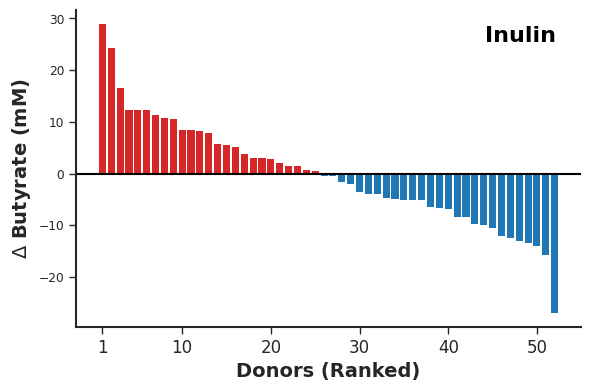

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

# =============================================================================
# 1. Visualization Settings
# =============================================================================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['svg.fonttype'] = 'none'
DPI_SETTING = 600

def clean_and_convert(vals):
    s_vals = vals.astype(str)
    s_vals = s_vals.replace(['Undetermined', '-', 'nan', '#VALUE!'], '0')
    return pd.to_numeric(s_vals, errors='coerce').fillna(0)

# =============================================================================
# 2. Data Loading and Processing
# =============================================================================
df_but = pd.read_csv('Butyrate(mM).csv')
donor_cols = [c for c in df_but.columns if c.startswith('HS-')]

but_ctrl = clean_and_convert(df_but.loc[df_but['KULFFI'] == 'Control', donor_cols].iloc[0])
but_inulin = clean_and_convert(df_but.loc[df_but['KULFFI'] == 'Inulin', donor_cols].iloc[0])

delta_but = but_inulin - but_ctrl

# Sort values for the waterfall plot
df_waterfall = pd.DataFrame({'Delta': delta_but.values})
df_waterfall = df_waterfall.sort_values('Delta', ascending=False).reset_index(drop=True)

# Assign colors (positive vs negative/zero)
colors = ['#d62728' if x > 0 else '#1f77b4' for x in df_waterfall['Delta']]

# =============================================================================
# 3. Plotting
# =============================================================================
fig, ax = plt.subplots(figsize=(6, 4))

ax.bar(df_waterfall.index, df_waterfall['Delta'], color=colors, width=0.8, edgecolor='none')

ax.set_ylabel(r'$\Delta$ Butyrate (mM)', fontsize=14, fontweight='bold')
ax.set_xlabel('Donors (Ranked)', fontsize=14, fontweight='bold')

num_donors = len(df_waterfall)
tick_positions = [0, 9, 19, 29, 39, 49]
tick_labels = ['1', '10', '20', '30', '40', '50']

valid_ticks = [p for p in tick_positions if p < num_donors]
valid_labels = tick_labels[:len(valid_ticks)]

ax.set_xticks(valid_ticks)
ax.set_xticklabels(valid_labels, fontsize=12)

# Baseline
ax.axhline(0, color='black', linewidth=1.5)

# Frame setup
for spine in ['left', 'bottom']:
    ax.spines[spine].set_linewidth(1.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add label
ax.text(0.95, 0.95, 'Inulin', transform=ax.transAxes,
        fontsize=16, fontweight='bold', va='top', ha='right', color='black')

plt.tight_layout()

# =============================================================================
# 4. Output Generation
# =============================================================================
plt.savefig('Figure_4e.pdf', dpi=DPI_SETTING, bbox_inches='tight')